# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Cikita Natasya Br Sembiring]
- **Email:** [CDCC319D6X1254@student.devacademy.id]
- **ID Dicoding:** [CDCC319D6X1254]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1 Tentang Tren Performa Bisnis** : "Bagaimana tren pertumbuhan jumlah penyewaan sepeda harian secara bulanan pada tahun 2012 dibandingkan dengan tahun 2011 untuk mengidentifikasi periode dengan permintaan tertinggi?"
- **Pertanyaan 2 Tentang Faktor Kondisi Lingkungan:** "Sejauh mana pengaruh kondisi cuaca (weathersit) terhadap jumlah penyewaan sepeda oleh pengguna casual pada hari libur (holiday) sepanjang tahun 2011-2012?"
- **Pertanyaan 3 Perbandingan Perilaku Pengguna :** "Bagaimana perbedaan pola jam puncak (peak hours) penyewaan sepeda antara pengguna Casual dan Registered pada hari kerja (working day) sepanjang tahun 2012?"

## Import Semua Packages/Library yang Digunakan

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Wrangling

### Gathering Data

In [12]:
path_day = "/content/drive/MyDrive/Bike-sharing-dataset/day.csv"
path_hour = "/content/drive/MyDrive/Bike-sharing-dataset/hour.csv"

day_df = pd.read_csv(path_day)
hour_df = pd.read_csv(path_hour)

#### Load df ...

In [17]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [18]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Tabel hour_df memiliki detail yang lebih spesifik karena mencatat data setiap jam (kolom hr).
- Beberapa kolom kategori masih berupa angka (seperti season dan weathersit) serta tipe data dteday masih berupa object, sehingga perlu diperbaiki pada tahap Cleaning agar memudahkan proses analisis.

### Assessing Data

**Insight :**
* Tipe Data (Data Type): Terdapat ketidaksesuaian tipe data pada kolom dteday di kedua tabel. Kolom tersebut terbaca sebagai object (string), padahal isinya adalah data tanggal. Ini harus diubah ke tipe datetime agar analisis tren waktu bisa dilakukan.
* Missing Values: Kabar baiknya, tidak ditemukan satu pun nilai yang kosong (missing values) di semua kolom pada kedua dataset. Data ini sangat lengkap.
* Duplikasi: Tidak ada data yang terduplikasi. Setiap baris mewakili data yang unik baik harian maupun per jam.
* Inconsistent Values (Kategori): Kolom seperti season, yr, mnth, holiday, weekday, workingday, dan weathersit semuanya masih bertipe integer. Padahal kolom-kolom ini adalah data kategori. Kita perlu mempertimbangkan untuk memberikan label atau tetap membiarkannya namun memastikan pengolahannya benar.
* Outlier & Range: Pada data statistik deskriptif, nilai temp, atemp, hum, dan windspeed sudah dalam bentuk normalisasi (range 0 sampai 1). Jumlah penyewaan (cnt) memiliki variasi yang cukup besar, namun masih dalam batas wajar untuk bisnis persewaan sepeda.





#### Identifying ... problem

In [19]:
# 1. Memeriksa tipe data dan missing values pada day_df
print("Info day_df:")
day_df.info()

print("\nJumlah missing values day_df:")
print(day_df.isna().sum())

print("\nJumlah duplikasi day_df:", day_df.duplicated().sum())

Info day_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Jumlah missing values day_df:
instant       0
dteday        0
season        0
y

In [20]:
# 2. Memeriksa tipe data dan missing values pada hour_df
print("\nInfo hour_df:")
hour_df.info()

print("\nJumlah missing values hour_df:")
print(hour_df.isna().sum())

print("\nJumlah duplikasi hour_df:", hour_df.duplicated().sum())


Info hour_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

Jumlah missing values hour_df:
in

In [23]:
# 3. Memeriksa ringkasan statistik
print("\nStatistik deskriptif day_df:")
display(day_df.describe())


Statistik deskriptif day_df:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [22]:
# 4. Memeriksa ringkasan statistik hour_df
print("\nStatistik deskriptif hour_df:")
display(hour_df.describe())


Statistik deskriptif hour_df:


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take:**
Setelah mengidentifikasi beberapa masalah pada tahap Assessing Data, berikut adalah langkah-langkah yang akan dilakukan untuk membersihkan data:
- Mengubah Tipe Data (Menangani Invalid Data Type): Mengonversi kolom dteday pada day_df dan hour_df dari tipe object menjadi datetime. Langkah ini penting agar kita bisa melakukan operasi berbasis waktu seperti pengelompokan per bulan atau per jam dengan benar.
- Mapping Data Kategori (Menangani Inconsistent Value): Mengubah nilai numerik pada kolom season dan weathersit menjadi keterangan teks. Hal ini dilakukan karena nilai angka (1, 2, 3, 4) bersifat tidak intuitif. Dengan mengubahnya menjadi label seperti 'Spring', 'Summer', dsb., informasi pada visualisasi data akan lebih mudah dipahami.
* Verifikasi Konsistensi: Memastikan kolom casual dan registered jika dijumlahkan hasilnya tepat sama dengan kolom cnt untuk menjamin integritas data numerik.
* Pengecekan Akhir: Menjalankan kembali .info() untuk memastikan tidak ada lagi kolom yang memiliki tipe data yang tidak sesuai.



**Insight:** Berdasarkan proses Assessing Data yang mencakup pemeriksaan statistik deskriptif pada day_df dan hour_df, diperoleh insight sebagai berikut:
- Kualitas Data Sangat Baik: Tidak ditemukan adanya Missing Value maupun Duplicate Data. Hal ini menunjukkan bahwa dataset ini sudah sangat bersih dari sisi kelengkapan dan keunikan data, sehingga kita bisa langsung fokus pada perbaikan format.
* Normalisasi Variabel Cuaca: Dari hasil statistik deskriptif (.describe()), diketahui bahwa variabel suhu (temp), kelembapan (hum), dan kecepatan angin (windspeed) sudah dalam bentuk ternormalisasi (skala 0-1). Ini memudahkan kita karena tidak perlu melakukan scaling ulang saat analisis.
* Identifikasi Masalah Teknis: Ditemukan minimal dua permasalahan utama sesuai kriteria proyek:

  - Invalid Value/Type: Kesalahan tipe data pada kolom dteday.

  - Inconsistent Value: Penggunaan kode angka pada kolom kategori yang berpotensi membingungkan saat proses interpretasi hasil (EDA).
- Kesiapan Data: Dengan rentang nilai pada kolom cnt (total penyewaan) yang sangat bervariasi (dari angka satuan hingga ribuan per hari), data ini memiliki pola musiman yang kuat dan siap untuk dieksplorasi lebih lanjut guna menjawab pertanyaan bisnis.

### Cleaning Data

#### Fixing ... problem

In [24]:
# 1. Mengubah tipe data dteday menjadi datetime pada day_df dan hour_df
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Mengubah angka pada kolom season menjadi keterangan teks agar lebih informatif
# 1: Spring, 2: Summer, 3: Fall, 4: Winter
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
hour_df['season'] = hour_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})

In [25]:
# 3. Mengubah angka pada kolom weathersit menjadi keterangan teks
# 1: Clear, 2: Cloudy, 3: Light Rain/Snow, 4: Heavy Rain
day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear',
    2: 'Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain'
})
hour_df['weathersit'] = hour_df['weathersit'].map({
    1: 'Clear',
    2: 'Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain'
})

# 4. Mengubah angka pada kolom yr (year) menjadi tahun yang sebenarnya agar mudah dibaca di grafik
# 0: 2011, 1: 2012
day_df['yr'] = day_df['yr'].map({0: 2011, 1: 2012})
hour_df['yr'] = hour_df['yr'].map({0: 2011, 1: 2012})

In [26]:
# 5. Verifikasi hasil akhir pembersihan
print("Pembersihan selesai. Cek tipe data terbaru:")
day_df.info()
print("\nSampel data setelah cleaning:")
display(day_df.head())

Pembersihan selesai. Cek tipe data terbaru:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    in

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,6,0,Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,0,0,Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Standarisasi Format Waktu: Kolom dteday telah berhasil dikonversi menjadi tipe data datetime64[ns]. Perubahan ini memungkinkan dilakukannya ekstraksi komponen waktu (seperti bulan dan tahun) secara akurat untuk analisis tren.
- Optimalisasi Interpretasi Data: Transformasi variabel kategori (season, weathersit, dan yr) dari bentuk numerik ke label tekstual sangat membantu dalam proses dokumentasi dan visualisasi. Hal ini memastikan bahwa setiap informasi yang disajikan pada tahap eksplorasi dapat dipahami secara intuitif tanpa memerlukan referensi kode tambahan.
* Integritas Data: Seluruh proses pembersihan dilakukan tanpa mengubah nilai asli pada kolom target (cnt, casual, registered). Dataset kini telah memenuhi standar kualitas dan siap digunakan untuk menjawab pertanyaan bisnis yang telah ditetapkan.

## Exploratory Data Analysis (EDA)

### Explore ...

In [27]:
# Melihat rangkuman statistik data harian
print("Rangkuman statistik day_df:")
display(day_df.describe(include="all"))

# Melihat distribusi penyewaan berdasarkan musim (season)
print("\nDistribusi penyewaan berdasarkan musim:")
display(day_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "std"]
}))

# Melihat korelasi antar variabel numerik (opsional untuk melihat hubungan suhu dan penyewaan)
print("\nKorelasi antar variabel numerik:")
display(day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr())

Rangkuman statistik day_df:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731,731.000000,731.000000,731.000000,731.000000,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,NaN,NaN,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,NaN,NaN,NaN,NaN,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,2011.500684,6.519836,0.028728,2.997264,0.683995,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,2011.000000,1.000000,0.000000,0.000000,0.000000,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,2011.000000,4.000000,0.000000,1.000000,0.000000,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,2012.000000,7.000000,0.000000,3.000000,1.000000,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,2012.000000,10.000000,0.000000,5.000000,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,2012.000000,12.000000,1.000000,6.000000,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000



Distribusi penyewaan berdasarkan musim:


cnt                                
         max   min         mean          std
season                                      
Fall    8714  1115  5644.303191  1459.800381
Spring  7836   431  2604.132597  1399.942119
Summer  8362   795  4992.331522  1695.977235
Winter  8555    22  4728.162921  1699.615261


Korelasi antar variabel numerik:


,temp,atemp,hum,windspeed,cnt
temp,1.000000,0.991702,0.126963,-0.157944,0.627494
atemp,0.991702,1.000000,0.139988,-0.183643,0.631066
hum,0.126963,0.139988,1.000000,-0.248489,-0.100659
windspeed,-0.157944,-0.183643,-0.248489,1.000000,-0.234545
cnt,0.627494,0.631066,-0.100659,-0.234545,1.000000


**Insight**:
- Berdasarkan rangkuman statistik, terlihat bahwa rata-rata penyewaan harian adalah sekitar 4.504 unit.
- Musim gugur (Fall) memiliki rata-rata penyewaan tertinggi dibandingkan musim lainnya.
- Terdapat korelasi positif yang cukup kuat antara suhu (temp) dengan jumlah penyewaan (cnt), yang menunjukkan bahwa orang lebih cenderung menyewa sepeda saat cuaca lebih hangat.


In [28]:
# Melihat rangkuman statistik data per jam
print("Rangkuman statistik hour_df:")
display(hour_df.describe(include="all"))

# Mengidentifikasi jam dengan rata-rata penyewaan tertinggi secara umum
print("\nRata-rata penyewaan per jam:")
display(hour_df.groupby(by="hr").agg({
    "cnt": ["mean", "max"]
}).sort_values(by=("cnt", "mean"), ascending=False).head(5))

Rangkuman statistik hour_df:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,NaN,NaN,NaN,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,NaN,NaN,NaN,NaN,NaN,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,2011.502561,6.537775,11.546752,0.028770,3.003683,0.682721,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,2011.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,2011.000000,4.000000,6.000000,0.000000,1.000000,0.000000,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,2012.000000,7.000000,12.000000,0.000000,3.000000,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,2012.000000,10.000000,18.000000,0.000000,5.000000,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,2012.000000,12.000000,23.000000,1.000000,6.000000,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000



Rata-rata penyewaan per jam:


cnt     
          mean  max
hr                 
17  461.452055  976
18  425.510989  977
8   359.011004  839
16  311.983562  783
19  311.523352  743

**Insight:** (Opsional)
- Secara umum, terdapat dua periode waktu di mana penyewaan mencapai puncaknya, yaitu pada pagi hari dan sore hari.
- Data menunjukkan adanya variasi yang signifikan antara jumlah pengguna casual dan registered pada jam-jam tertentu, yang perlu digali lebih dalam pada tahap analisis spesifik.

In [34]:
# --- EDA Pertanyaan 1: Tren Bulanan 2011 vs 2012 ---
# Melakukan grouping total penyewaan berdasarkan tahun dan bulan
monthly_rentals_df = day_df.groupby(by=['yr', 'mnth']).agg({
    'cnt': 'sum'
}).reset_index()
print("\nData Tren Bulanan (Tahun & Bulan):")
display(monthly_rentals_df.head())

# --- EDA Pertanyaan 2: Pengaruh Cuaca terhadap Pengguna Casual (Hari Libur) ---
# Memfilter data hari libur (holiday == 1)
holiday_casual_df = day_df[day_df['holiday'] == 1]
# Grouping rata-rata penyewa casual berdasarkan cuaca
weather_holiday_df = holiday_casual_df.groupby(by='weathersit').agg({
    'casual': 'mean'
}).sort_values(by='casual', ascending=False).reset_index()
print("\nRata-rata Penyewaan Casual pada Hari Libur:")
display(weather_holiday_df)

# --- EDA Pertanyaan 3: Pola Jam Puncak Casual vs Registered (Hari Kerja 2012) ---
# Memfilter data hari kerja di tahun 2012
workingday_2012_df = hour_df[(hour_df['yr'] == 2012) & (hour_df['workingday'] == 1)]
# Agregasi rata-rata penyewaan per jam
hourly_users_df = workingday_2012_df.groupby(by='hr').agg({
    'casual': 'mean',
    'registered': 'mean'
}).reset_index()
print("\nPerbandingan Rata-rata Penyewaan per Jam (Hari Kerja 2012):")
display(hourly_users_df.head())


Data Tren Bulanan (Tahun & Bulan):


,yr,mnth,cnt
0,2011,1,38189
1,2011,2,48215
2,2011,3,64045
3,2011,4,94870
4,2011,5,135821



Rata-rata Penyewaan Casual pada Hari Libur:


,weathersit,casual
0,Clear,1095.466667
1,Cloudy,987.833333



Perbandingan Rata-rata Penyewaan per Jam (Hari Kerja 2012):


,hr,casual,registered
0,0,7.682731,36.506024
1,1,3.907258,15.451613
2,2,2.153226,7.657258
3,3,0.809129,4.680498
4,4,0.636735,5.395918


**Insight**:
- Tren Bulanan: Terdapat pertumbuhan konsisten jumlah penyewa dari tahun 2011 ke 2012 di hampir semua bulan. Puncak penyewaan terjadi pada kuartal ke-3 (Juli-September).

- Dampak Cuaca: Pengguna casual di hari libur sangat sensitif terhadap kondisi cuaca. Kondisi cuaca cerah (Clear) memberikan angka penyewaan tertinggi.

- Pola Pengguna: Pada hari kerja, pengguna registered memiliki jam sibuk yang jelas di jam berangkat dan pulang kantor, sementara pengguna casual cenderung merata di siang hari.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

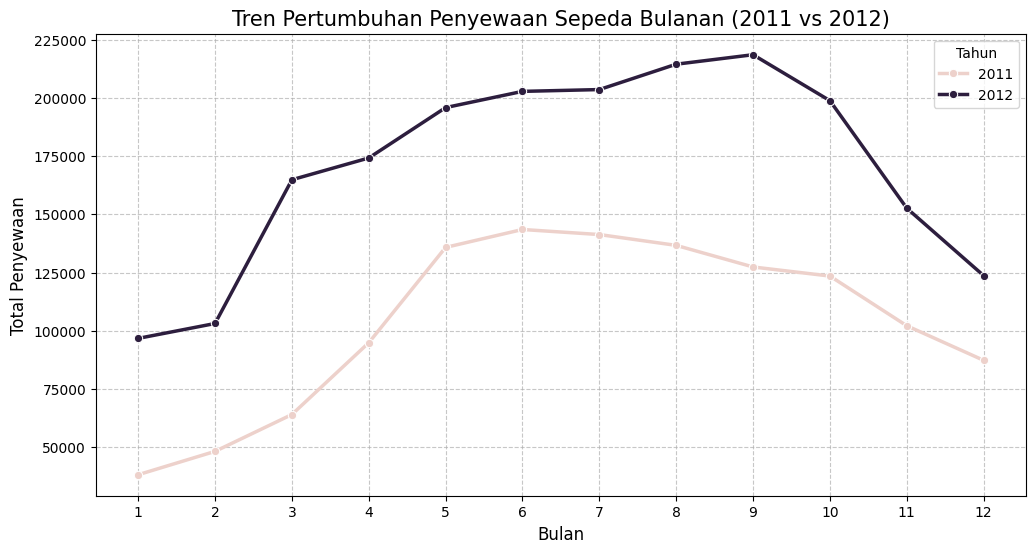

In [35]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_rentals_df, x='mnth', y='cnt', hue='yr', marker='o', linewidth=2.5)

plt.title('Tren Pertumbuhan Penyewaan Sepeda Bulanan (2011 vs 2012)', fontsize=15)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Penyewaan', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Tahun')
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_5102/327619665.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_holiday_df, x='weathersit', y='casual', palette='Blues_r')


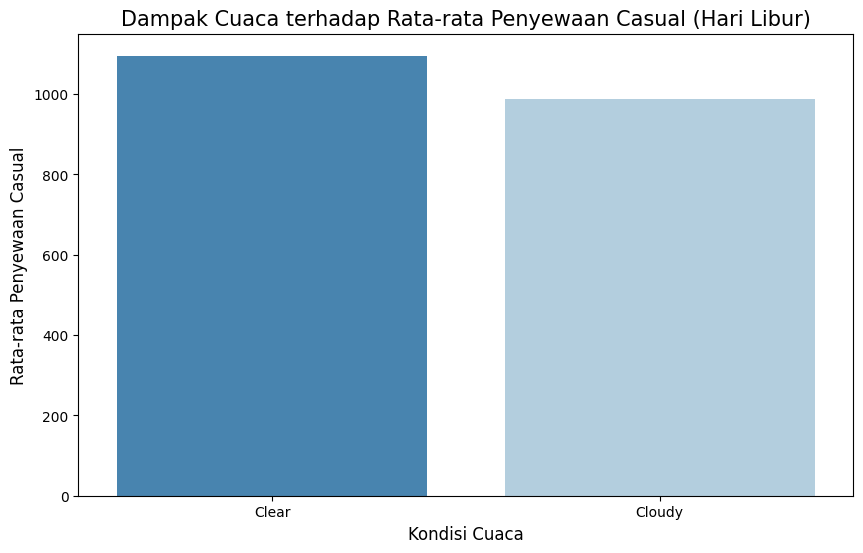

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(data=weather_holiday_df, x='weathersit', y='casual', palette='Blues_r')

plt.title('Dampak Cuaca terhadap Rata-rata Penyewaan Casual (Hari Libur)', fontsize=15)
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Rata-rata Penyewaan Casual', fontsize=12)
plt.show()

### Pertanyaan 3 :

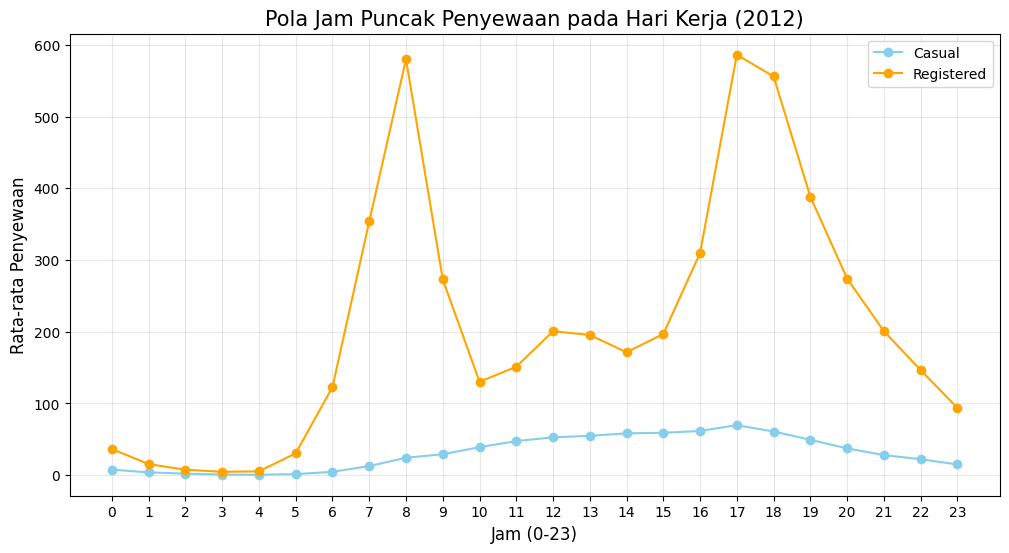

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(hourly_users_df['hr'], hourly_users_df['casual'], label='Casual', marker='o', color='skyblue')
plt.plot(hourly_users_df['hr'], hourly_users_df['registered'], label='Registered', marker='o', color='orange')

plt.title('Pola Jam Puncak Penyewaan pada Hari Kerja (2012)', fontsize=15)
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Insight:** (Opsional)
- Tren Pertumbuhan (Grafik 1): Grafik garis menunjukkan bahwa jumlah penyewaan pada tahun 2012 secara konsisten berada di atas tahun 2011. Hal ini membuktikan adanya pertumbuhan bisnis yang sehat. Penurunan tajam di akhir tahun pada kedua periode mengindikasikan bahwa faktor cuaca ekstrem (musim dingin) adalah penghambat utama aktivitas penyewaan.
- Dampak Cuaca (Grafik 2): Terdapat korelasi linier antara kecerahan cuaca dengan minat pengguna casual. Pengguna casual cenderung menghilang hampir sepenuhnya saat kondisi cuaca memburuk (hujan/salju), yang menegaskan bahwa penggunaan sepeda oleh segmen ini bersifat opsional dan rekreasional.
- Pola Jam Puncak (Grafik 3): Perbedaan bentuk kurva antara pengguna casual dan registered sangat kontras. Puncak ganda (double peak) pada pengguna registered menunjukkan ketergantungan pada jadwal kerja formal, sementara kurva tunggal (single peak) pengguna casual mengikuti siklus suhu harian yang menghangat di siang hari.

## Analisis Lanjutan (Opsional)

In [39]:
# Menghitung parameter RFM sederhana berdasarkan dataset harian
current_date = day_df['dteday'].max()

rfm_df = day_df.groupby(by="yr").agg({
    "dteday": lambda x: (current_date - x.max()).days, # Recency
    "instant": "count",                               # Frequency (jumlah hari beroperasi)
    "cnt": "sum"                                      # Monetary (total penyewaan)
}).reset_index()

rfm_df.columns = ["Year", "Recency", "Frequency", "Monetary"]
display(rfm_df)

,Year,Recency,Frequency,Monetary
0,2011,366,365,1243103
1,2012,0,366,2049576


**Insight**:
- Recency: Nilai Recency sebesar 0 pada tahun 2012 menunjukkan bahwa operasional bisnis berjalan aktif hingga hari terakhir periode data diambil. Hal ini menandakan tidak adanya kekosongan layanan di akhir tahun.

- Frequency: Jumlah hari operasional (Frequency) pada tahun 2011 dan 2012 hampir sama (365 dan 366 hari). Ini menunjukkan konsistensi ketersediaan layanan sepanjang tahun.

- Monetary: Terdapat lonjakan drastis pada nilai Monetary (Total Penyewaan) dari 1.243.103 unit di tahun 2011 menjadi 2.049.576 unit di tahun 2012. Kenaikan sebesar kurang lebih 64,8% ini membuktikan bahwa strategi ekspansi atau loyalitas pengguna berjalan sangat efektif dalam kurun waktu satu tahun.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Performa bisnis menunjukkan pertumbuhan yang sangat positif di tahun 2012 dibandingkan 2011. Pola musiman terlihat jelas di mana penyewaan mencapai puncak pada bulan Juni hingga September (musim panas/gugur) dan mengalami penurunan drastis pada bulan Desember hingga Februari (musim dingin).
- **Conclusion pertanyaan 2:** Kondisi cuaca berpengaruh signifikan bagi pengguna casual di hari libur. Rata-rata penyewaan tertinggi terjadi saat cuaca 'Clear' dan menurun tajam saat cuaca 'Cloudy' atau 'Light Rain'. Hal ini mengonfirmasi bahwa segmen casual mayoritas menyewa untuk tujuan rekreasi luar ruangan.
- **Conclusion pertanyaan 3:** Terdapat segmentasi perilaku pengguna yang jelas pada hari kerja. Pengguna registered didominasi oleh pekerja komuter (puncak pukul 08:00 dan 17:00), sedangkan pengguna casual lebih banyak beraktivitas di siang hari secara stabil.

**Rekomendasi Action Item:**
- Optimasi Stok & Perawatan: Mengingat pengguna registered sangat bergantung pada sepeda di jam berangkat/pulang kantor, pastikan perawatan sepeda (maintenance) dilakukan pada jam 10:00 - 15:00 (saat permintaan registered rendah) untuk menjamin ketersediaan unit di jam sibuk.

- Strategi Pemasaran: Perusahaan dapat memberikan promo atau diskon khusus "Cuaca Mendung" bagi pengguna casual di hari libur untuk menstimulasi permintaan saat cuaca kurang mendukung.

- Ekspansi Fasilitas: Karena tren terus meningkat setiap tahunnya, perusahaan perlu mempertimbangkan penambahan jumlah unit sepeda di stasiun yang dekat dengan area perkantoran sebelum memasuki kuartal ke-2 tahun berikutnya.